In [1]:
# ================================================
# # Project 3: Supply Chain Performance Analysis
# **Analyst:** Sachin Malee
# **Dataset:** DataCo Supply Chain (Kaggle)
# **Rows:** 1,80,519 | **Columns:** 43
# **Tools:** Python, Pandas, Matplotlib, Seaborn
# ================================================

In [2]:
# ================================================
# Libraries
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# ================================================
# Load Data
# ================================================
path = "C:/Users/srmal/OneDrive/Desktop/Supply Chain Performance Analysis/"

df = pd.read_csv(
    path + 'supply_chain_clean.csv',
    encoding='latin1',
    low_memory=False)

print(f"✅ Data loaded!")
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nDelivery Status:")
print(df['delivery_status'].value_counts())
print(f"\nOrder Status:")
print(df['order_status'].value_counts())
print(f"\nShipping Mode:")
print(df['shipping_mode'].value_counts())

✅ Data loaded!
Rows:    180,519
Columns: 43

Delivery Status:
delivery_status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Order Status:
order_status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Shipping Mode:
shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [4]:
# ================================================
# Data Cleaning
# ================================================

print("BEFORE cleaning:")
print(f"  Rows:  {len(df):,}")


df['order_date'] = pd.to_datetime(
    df['order_date'], errors='coerce')


df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='%d-%m-%Y',
    errors='coerce')


df['order_year']       = df['order_date'].dt.year
df['order_month']      = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_quarter']    = df['order_date'].dt.quarter


df['actual_delay'] = (
    df['days_shipping_real'] -
    df['days_shipment_scheduled'])
# Negative = early, Positive = late

df['is_profitable'] = (
    df['profit'] > 0).astype(int)

df['discount_band'] = pd.cut(
    df['discount_rate'],
    bins=[-0.01, 0, 0.05,
          0.10, 0.20, 1.0],
    labels=['No Discount','Low (1-5%)',
            'Medium (6-10%)',
            'High (11-20%)',
            'Very High (20%+)'])

df['profit_band'] = pd.cut(
    df['profit'],
    bins=[-float('inf'), 0, 50,
          200, float('inf')],
    labels=['Loss','Low Profit',
            'Medium Profit',
            'High Profit'])

print("\nAFTER cleaning:")
print(f"  Rows: {len(df):,}")
print(f"  Late Risk: "
      f"{df['late_delivery_risk'].mean()*100:.1f}%")
print(f"  Loss Orders: "
      f"{(df['profit']<0).sum():,} "
      f"({(df['profit']<0).mean()*100:.1f}%)")
print("\n✅ New columns added!")

BEFORE cleaning:
  Rows:  180,519

AFTER cleaning:
  Rows: 180,519
  Late Risk: 54.8%
  Loss Orders: 33,784 (18.7%)

✅ New columns added!


In [5]:
# ================================================
# Key Insights
# ================================================

print("="*55)
print("📊 SUPPLY CHAIN — KEY INSIGHTS")
print("="*55)

print(f"\n📦 Total Orders:      "
      f"{df['order_id'].nunique():,}")
print(f"👥 Total Customers:   "
      f"{df['customer_id'].nunique():,}")
print(f"💰 Total Revenue:     "
      f"${df['sales'].sum():,.0f}")
print(f"💵 Total Profit:      "
      f"${df['profit'].sum():,.0f}")
print(f"📊 Avg Profit Margin: "
      f"{df['profit_ratio'].mean()*100:.1f}%")
print(f"🚨 Late Delivery:     "
      f"{df['late_delivery_risk'].mean()*100:.1f}%")
print(f"❌ Loss Orders:       "
      f"{(df['profit']<0).sum():,} "
      f"({(df['profit']<0).mean()*100:.1f}%)")

print("\n🏪 Department Revenue:")
dept = (df.groupby('department_name')
    ['profit'].sum()
    .sort_values(ascending=False)
    .head(5))
for d, p in dept.items():
    print(f"   {d}: ${p:,.0f}")

print("\n🌍 Market Performance:")
mkt = (df.groupby('market')
    ['profit'].sum()
    .sort_values(ascending=False))
for m, p in mkt.items():
    print(f"   {m}: ${p:,.0f}")

print("\n🚚 Late Risk by Shipping Mode:")
ship = (df.groupby('shipping_mode')
    ['late_delivery_risk'].mean()*100
    ).sort_values(ascending=False)
for s, r in ship.items():
    print(f"   {s}: {r:.1f}%")

print("\n⚠️ Discount Impact:")
disc = (df.groupby('discount_band')
    ['profit'].mean()
    .round(2))
for d, p in disc.items():
    status = '✅' if p > 0 else '❌'
    print(f"   {status} {d}: ${p:.2f} avg profit")

📊 SUPPLY CHAIN — KEY INSIGHTS

📦 Total Orders:      65,752
👥 Total Customers:   20,652
💰 Total Revenue:     $33,054,402
💵 Total Profit:      $3,966,903
📊 Avg Profit Margin: 12.1%
🚨 Late Delivery:     54.8%
❌ Loss Orders:       33,784 (18.7%)

🏪 Department Revenue:
   Fan Shop: $1,834,155
   Apparel: $881,883
   Golf: $497,524
   Footwear: $410,222
   Outdoors: $145,251

🌍 Market Performance:
   Europe: $1,169,443
   LATAM: $1,123,322
   Pacific Asia: $857,753
   USCA: $564,314
   Africa: $252,071

🚚 Late Risk by Shipping Mode:
   First Class: 95.3%
   Second Class: 76.6%
   Same Day: 45.7%
   Standard Class: 38.1%

⚠️ Discount Impact:
   ✅ No Discount: $26.67 avg profit
   ✅ Low (1-5%): $23.26 avg profit
   ✅ Medium (6-10%): $23.51 avg profit
   ✅ High (11-20%): $20.71 avg profit
   ✅ Very High (20%+): $18.41 avg profit


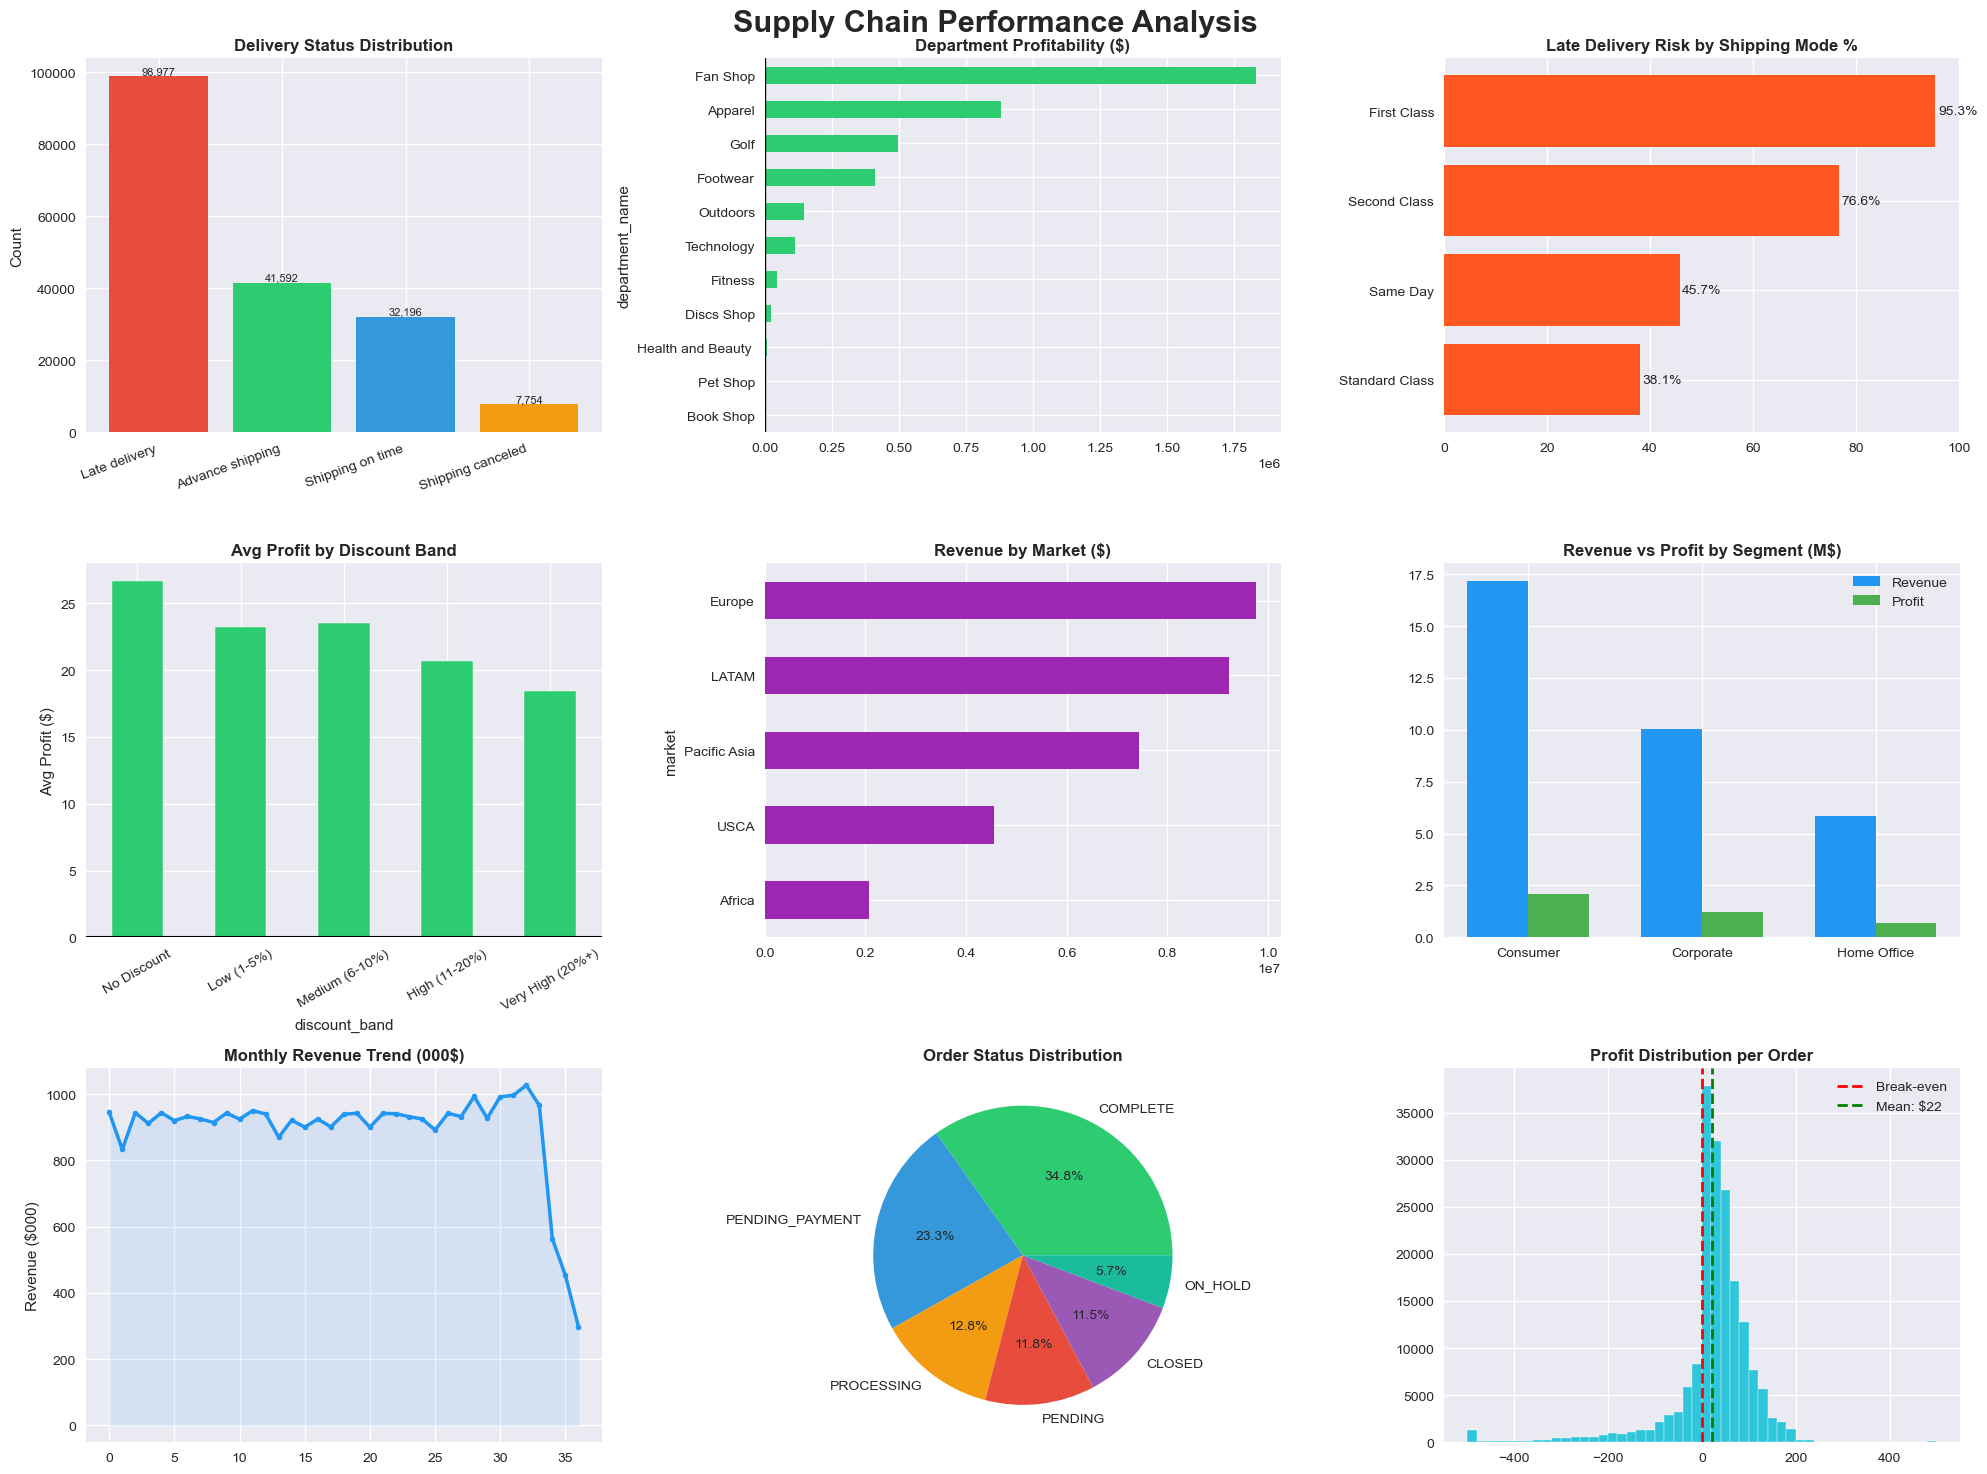

✅ All graphs saved!


In [6]:
# ================================================
# Visualizations
# ================================================

fig, axes = plt.subplots(3, 3,
    figsize=(20, 15))
fig.suptitle(
    'Supply Chain Performance Analysis',
    fontsize=22, fontweight='bold')

# Graph 1 — Delivery Status
ax1 = axes[0,0]
del_status = df['delivery_status'].value_counts()
colors1 = ['#e74c3c','#2ecc71',
           '#3498db','#f39c12']
ax1.bar(range(len(del_status)),
        del_status.values,
        color=colors1)
ax1.set_xticks(range(len(del_status)))
ax1.set_xticklabels(
    del_status.index,
    rotation=20, ha='right')
ax1.set_title('Delivery Status Distribution',
              fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(del_status.values):
    ax1.text(i, v+500,
             f'{v:,}',
             ha='center', fontsize=8)

# Graph 2 — Department Profitability
ax2 = axes[0,1]
dept_profit = (df.groupby('department_name')
    ['profit'].sum()
    .sort_values())
colors2 = ['#e74c3c' if x < 0
           else '#2ecc71'
           for x in dept_profit.values]
dept_profit.plot(kind='barh',
                 ax=ax2,
                 color=colors2)
ax2.axvline(0, color='black',
            linewidth=1)
ax2.set_title('Department Profitability ($)',
              fontweight='bold')

# Graph 3 — Shipping Mode vs Late Risk
ax3 = axes[0,2]
ship_late = (df.groupby('shipping_mode')
    ['late_delivery_risk'].mean()*100
    ).sort_values(ascending=True)
bars = ax3.barh(ship_late.index,
                ship_late.values,
                color='#FF5722')
ax3.set_title(
    'Late Delivery Risk by Shipping Mode %',
    fontweight='bold')
for bar, val in zip(bars, ship_late.values):
    ax3.text(val+0.5, bar.get_y() +
             bar.get_height()/2,
             f'{val:.1f}%',
             va='center', fontsize=10)

# Graph 4 — Discount vs Profit
ax4 = axes[1,0]
disc_profit = (df.groupby('discount_band')
    ['profit'].mean()
    .fillna(0))
colors4 = ['#2ecc71' if x > 0
           else '#e74c3c'
           for x in disc_profit.values]
disc_profit.plot(kind='bar',
                 ax=ax4,
                 color=colors4,
                 edgecolor='white')
ax4.axhline(0, color='black',
            linewidth=1.5)
ax4.set_title('Avg Profit by Discount Band',
              fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
ax4.set_ylabel('Avg Profit ($)')

# Graph 5 — Market Revenue
ax5 = axes[1,1]
mkt_rev = (df.groupby('market')
    ['sales'].sum()
    .sort_values(ascending=True))
mkt_rev.plot(kind='barh',
             ax=ax5,
             color='#9C27B0')
ax5.set_title('Revenue by Market ($)',
              fontweight='bold')

# Graph 6 — Customer Segment
ax6 = axes[1,2]
seg_data = (df.groupby('customer_segment')
    .agg(revenue=('sales','sum'),
         profit=('profit','sum'))
    .reset_index())
x = range(len(seg_data))
width = 0.35
ax6.bar([i-width/2 for i in x],
        seg_data['revenue']/1e6,
        width, label='Revenue',
        color='#2196F3')
ax6.bar([i+width/2 for i in x],
        seg_data['profit']/1e6,
        width, label='Profit',
        color='#4CAF50')
ax6.set_xticks(x)
ax6.set_xticklabels(
    seg_data['customer_segment'])
ax6.set_title(
    'Revenue vs Profit by Segment (M$)',
    fontweight='bold')
ax6.legend()

# Graph 7 — Monthly Revenue Trend
ax7 = axes[2,0]
monthly = (df.groupby(
    ['order_year','order_month'])
    ['sales'].sum().reset_index())
monthly = monthly.sort_values(
    ['order_year','order_month'])
ax7.plot(range(len(monthly)),
         monthly['sales']/1000,
         color='#2196F3',
         linewidth=2.5,
         marker='o', markersize=4)
ax7.fill_between(
    range(len(monthly)),
    monthly['sales']/1000,
    alpha=0.1, color='#2196F3')
ax7.set_title('Monthly Revenue Trend (000$)',
              fontweight='bold')
ax7.set_ylabel('Revenue ($000)')

# Graph 8 — Order Status
ax8 = axes[2,1]
ord_status = (df['order_status']
    .value_counts().head(6))
colors8 = ['#2ecc71','#3498db','#f39c12',
           '#e74c3c','#9b59b6','#1abc9c']
ax8.pie(ord_status.values,
        labels=ord_status.index,
        autopct='%1.1f%%',
        colors=colors8)
ax8.set_title('Order Status Distribution',
              fontweight='bold')

# Graph 9 — Profit Distribution
ax9 = axes[2,2]
profit_data = df['profit'].clip(-500, 500)
ax9.hist(profit_data, bins=50,
         color='#00BCD4',
         edgecolor='white',
         alpha=0.8)
ax9.axvline(0, color='red',
            linestyle='--',
            linewidth=2,
            label='Break-even')
ax9.axvline(df['profit'].mean(),
            color='green',
            linestyle='--',
            linewidth=2,
            label=f"Mean: "
                  f"${df['profit'].mean():.0f}")
ax9.set_title('Profit Distribution per Order',
              fontweight='bold')
ax9.legend()

plt.tight_layout()
plt.savefig(
    'supply_chain_analysis.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ All graphs saved!")

In [7]:
# ================================================
# Save Clean Data
# ================================================
df.to_csv(
    path + 'supply_chain_cleaned_final.csv',
    index=False)
print(f"✅ Clean data saved!")
print(f"   Rows: {len(df):,}")
print(f"   Cols: {len(df.columns)}")

✅ Clean data saved!
   Rows: 180,519
   Cols: 51
